In [1]:
# Core libraries for analysis, visualization and modelling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression  # Linear regression model
from sklearn.metrics import r2_score, mean_squared_error  # Model evaluation metrics

# Load cleaned dataset produced in 01_EDA.ipynb
df = pd.read_csv('../data/hyg_clean.csv')
print(df.shape)

(107859, 38)


In [2]:
# Regression only valid for main sequence stars — giants and white dwarfs
# follow different physics and would distort the temperature-luminosity relationship
# Luminosity class V = main sequence, IV excluded to avoid false matches
mask_ms = df['spect'].str.contains('V', na=False) & ~df['spect'].str.contains('IV', na=False)
df_ms = df[mask_ms].copy()
print(f"Main sequence stars: {len(df_ms):,}")

Main sequence stars: 23,935


In [3]:
# Apply log10 transforms to both luminosity and temperature
# Physics basis: Stefan-Boltzmann law gives L ∝ T^4
# Taking log10 of both sides linearises this: log(L) = 4 * log(T) + constant
# Log base 10 chosen for interpretability — each unit = 10x the value
df_ms['log_lum'] = np.log10(df_ms['lum'])
df_ms['log_temp'] = np.log10(df_ms['temp'])

# Verify transforms look sensible
df_ms.head()

,id,hip,hd,hr,gl,bf,proper,ra,dec,dist,...,comp,comp_primary,base,lum,var,var_min,var_max,temp,log_lum,log_temp
1,2,2.0,224690.0,NaN,NaN,NaN,NaN,0.000283,-19.498840,47.9616,...,1,2,NaN,0.392283,NaN,NaN,NaN,5002.605524,-0.4064,3.699196
3,4,4.0,224707.0,NaN,NaN,NaN,NaN,0.000569,-51.893546,134.2282,...,1,4,NaN,9.366989,NaN,NaN,NaN,7441.860465,0.9716,3.871682
5,6,6.0,NaN,NaN,NaN,NaN,NaN,0.001246,3.946458,55.0358,...,1,6,NaN,0.031420,NaN,12.462,12.162,4255.319149,-1.5028,3.628932
9,10,10.0,224717.0,NaN,NaN,NaN,NaN,0.002424,-50.866976,92.3361,...,1,10,NaN,2.721448,NaN,NaN,NaN,6813.342796,0.4348,3.833360
14,16,17.0,224732.0,NaN,NaN,NaN,NaN,0.003401,-40.192392,136.4256,...,1,16,NaN,8.904304,NaN,NaN,NaN,7137.546468,0.9496,3.853549


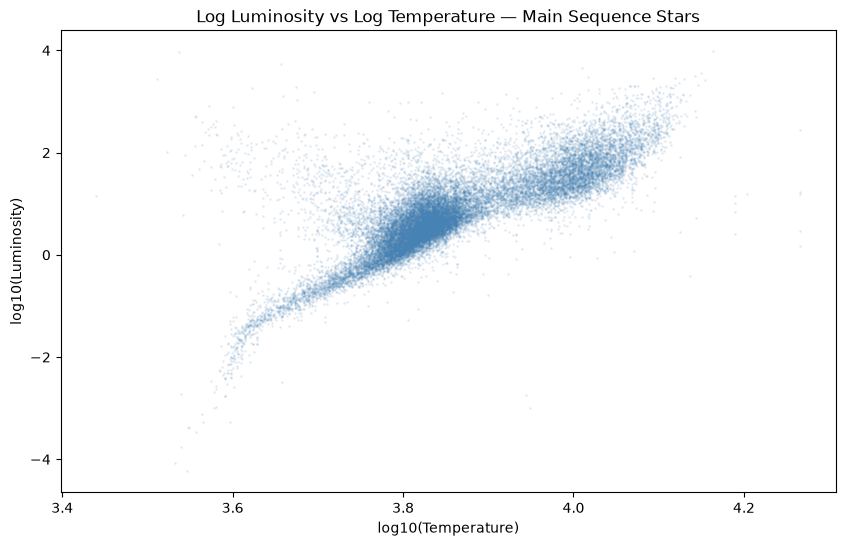

In [4]:
# Visualise relationship before fitting the model — always plot first
# alpha=0.1 and s=1 used because 23,935 points would otherwise blob together
# Clear positive linear trend confirms log-log transform was correct
plt.figure(figsize=(10, 6))
plt.scatter(df_ms['log_temp'], df_ms['log_lum'],
            alpha=0.1, s=1, color='steelblue')
plt.xlabel('log10(Temperature)')
plt.ylabel('log10(Luminosity)')
plt.title('Log Luminosity vs Log Temperature — Main Sequence Stars')
plt.show()

In [5]:
# X must be a 2D DataFrame (double brackets) — sklearn expects a feature matrix
# even when only one feature is used
# y is a 1D Series (single brackets) — the target variable to predict
X = df_ms[['log_temp']]
y = df_ms['log_lum']

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Slope: rate of change of log_lum per unit of log_temp
# Theory predicts slope ≈ 4 (Stefan-Boltzmann), observed 6.18 reflects
# the additional influence of the mass-luminosity relationship
print(f"Slope: {model.coef_[0]:.4f}")

# Intercept: mathematical anchor of the line — no physical meaning at log_temp = 0
# (would represent a star at 1K which is physically impossible)
print(f"Intercept: {model.intercept_:.4f}")

Slope: 6.1779
Intercept: -23.0120


In [6]:
# Generate predictions for all X values
y_pred = model.predict(X)

# R² score: proportion of luminosity variance explained by temperature alone
# 0.63 means temperature explains 63% of luminosity variation
r2 = r2_score(y, y_pred)

# RMSE: average prediction error in log10 luminosity units
# 0.49 log units ≈ factor of 3x in actual luminosity
# Scatter reflects genuine physical variation — mass, age, composition
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R² score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² score: 0.6290
RMSE: 0.4918


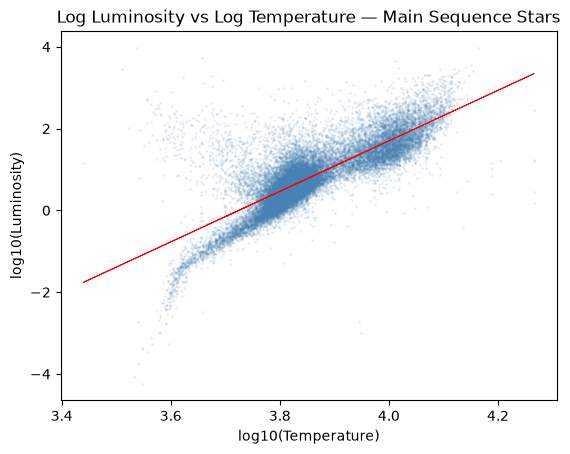

In [8]:
# Overlay fitted regression line on scatter plot
# Red line passes through the heart of the main sequence band
# Residual scatter above and below reflects multi-factor nature of stellar physics
plt.scatter(df_ms['log_temp'], df_ms['log_lum'], alpha=0.1, s=1, color='steelblue')
plt.plot(X, y_pred, color='red', linestyle="-", linewidth=0.7)

plt.xlabel('log10(Temperature)')
plt.ylabel('log10(Luminosity)')
plt.title('Log Luminosity vs Log Temperature — Main Sequence Stars')
plt.show()

## Conclusion

The regression model reveals a slope of 6.18 between log temperature and 
log luminosity for main sequence stars. While stellar theory (Stefan-Boltzmann) 
predicts a slope of 4, the steeper observed gradient reflects the influence of 
the mass luminosity relationship. Hotter main sequence stars tend to be more 
massive, amplifying their luminosity beyond what temperature alone would predict.

The model achieves an R² of 0.63, meaning approximately 63% of the variation 
in stellar luminosity is explained by temperature alone. This is a strong result 
for a single variable model, confirming that temperature is a dominant but 
incomplete predictor of luminosity.

The RMSE of 0.49 log units translates to predictions being off by roughly a 
factor of 3 in actual luminosity on average. This scatter is not model failure 
as it reflects genuine physical variation along the main sequence. The remaining 
37% of luminosity variation is likely driven by differences in stellar mass, age, 
chemical composition, and the presence of unresolved binary systems in the catalog.

Overall, the log log linear regression successfully captures the core 
temperature luminosity relationship on the main sequence, while the residual 
scatter points to the multi factor nature of stellar physics.